In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("It is working")

It is working


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('whitegrid')

In [3]:
import os
print(os.getcwd())

C:\Users\Quinzee


In [10]:
import pandas as pd

df = pd.read_csv("C:\Users\Quinzee\Downloads\911.csv")

df.head()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3968796281.py, line 3)

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Quinzee\Downloads\911.csv")

df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [ ]:
# Print shape
print(df.shape)

# Print column names
print(df.columns.tolist())

In [ ]:
# First 10 rows
print(df.head(10))

# Last 5 rows
print(df.tail(5))

In [ ]:
df.info()

df.describe()

In [ ]:
df['dept'] = df['title'].apply(lambda x: x.split(':')[0].strip())

df['reason'] = df['title'].apply(lambda x: x.split(':')[1].strip())

print(df[['title', 'dept', 'reason']].head())

In [ ]:
print(df['twp'].value_counts().head(5))

In [ ]:
ems_calls = df[df['dept'] == 'EMS']

print("Total EMS calls:", ems_calls.shape[0])

In [ ]:
print(df['zip'].isnull().sum())

df['zip'] = df['zip'].fillna(0)

print(df['zip'].isnull().sum())

In [ ]:
## C2 — NumPy: Numerical Analysis

In [ ]:
lat_arr = df['lat'].to_numpy()
lng_arr = df['lng'].to_numpy()

print("Lat dtype:", lat_arr.dtype)
print("Lat shape:", lat_arr.shape)

print("Lng dtype:", lng_arr.dtype)
print("Lng shape:", lng_arr.shape)

In [ ]:
print("Mean latitude:", np.mean(lat_arr))
print("Std latitude:", np.std(lat_arr))
print("Min latitude:", np.min(lat_arr))
print("Max latitude:", np.max(lat_arr))
print("Range:", np.max(lat_arr) - np.min(lat_arr))

In [ ]:
dept_counts = df['dept'].value_counts()
counts_arr = dept_counts.values

print("Department counts:\n", dept_counts)
print("NumPy array:", counts_arr)
print("Total calls:", np.sum(counts_arr))

In [ ]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
hour_arr = df['timeStamp'].dt.hour.to_numpy()

hour_counts = np.bincount(hour_arr)

print(hour_counts)

In [ ]:
day_calls = np.sum((hour_arr >= 8) & (hour_arr <= 18))
night_calls = np.sum((hour_arr < 8) | (hour_arr > 18))

print("Day calls:", day_calls)
print("Night calls:", night_calls)

In [ ]:
EMS has the highest number of 911 calls, showing it is the most frequent emergency department in the dataset.

EMS has the highest number of 911 calls, showing it is the most frequent emergency department in the dataset.

## C3 — Matplotlib Visualisations

In [12]:
dept_counts = df['dept'].value_counts()

plt.figure(figsize=(10,6))

plt.bar(dept_counts.index, dept_counts.values)

plt.title('Total Number of Calls by Department')
plt.xlabel('Department')
plt.ylabel('Number of Calls')

plt.show()

KeyError: 'dept'

The bar chart shows that EMS receives the highest number of emergency calls, followed by Traffic and Fire departments. This indicates that medical emergencies are the most common type of 911 call in the dataset.

In [ ]:
plt.figure(figsize=(12,5))

plt.hist(hour_arr, bins=24)

plt.title('Distribution of 911 Calls by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Calls')

plt.show()

The histogram shows that most 911 calls occur during daytime and afternoon hours, while fewer calls happen late at night. This may be because people are more active during the day, leading to more traffic accidents, medical emergencies, and other incidents.

In [ ]:
top_twp = df['twp'].value_counts().head(10)

plt.figure(figsize=(10,7))

plt.barh(top_twp.index, top_twp.values)

plt.title('Top 10 Townships by 911 Call Volume')
plt.xlabel('Number of Calls')
plt.ylabel('Township')

plt.show()

In [ ]:
top_twp = df['twp'].value_counts().head(10)

plt.figure(figsize=(10,7))

plt.barh(top_twp.index[::-1], top_twp.values[::-1])

plt.title('Top 10 Townships by 911 Call Volume')
plt.xlabel('Number of Calls')
plt.ylabel('Township')

plt.show()

The horizontal bar chart shows that LOWER MERION has the highest number of 911 calls among all townships. This suggests that it is one of the busiest and most populated areas in the dataset.

In [ ]:
df['month'] = df['timeStamp'].dt.month

monthly = df.groupby('month')['e'].count()

plt.figure(figsize=(10,5))

plt.plot(monthly.index, monthly.values)

plt.title('Total 911 Calls Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')

plt.show()

The line chart shows that January has the highest number of 911 calls, while September has the lowest. This may suggest seasonal patterns where emergencies are more common during the beginning of the year.

## C4 — Seaborn Statistical Visualisations

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='dept', palette='Set2')

plt.title('Number of Calls per Department')
plt.xlabel('Department')
plt.ylabel('Count')

plt.show()

The Seaborn countplot confirms that EMS has the highest number of calls, followed by Traffic and Fire departments. Seaborn provides a cleaner and more visually appealing presentation compared to basic Matplotlib charts.

In [ ]:
df['day_of_week'] = df['timeStamp'].dt.dayofweek
df['hour'] = df['timeStamp'].dt.hour

pivot = df.groupby(['day_of_week', 'hour'])['e'].count().unstack()

plt.figure(figsize=(14,6))

sns.heatmap(pivot, cmap='YlOrRd')

plt.title('Call Volume by Day and Hour')

plt.show()

The heatmap shows that emergency calls are lowest during early morning hours (0–6) and late night hours (22–23). The highest call activity occurs between 7 and 21 hours, indicating that most emergencies happen during daytime and evening when human activity is higher.

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

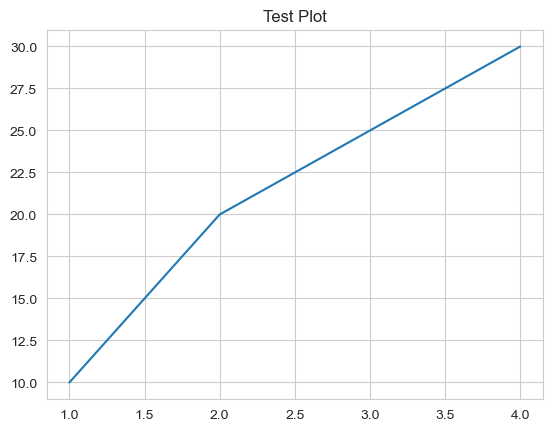

In [6]:
import matplotlib.pyplot as plt

plt.plot([1,2,3,4], [10,20,25,30])
plt.title("Test Plot")
plt.show()